# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [7]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [8]:
!ls MNIST

processed  raw


In [9]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [10]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [11]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

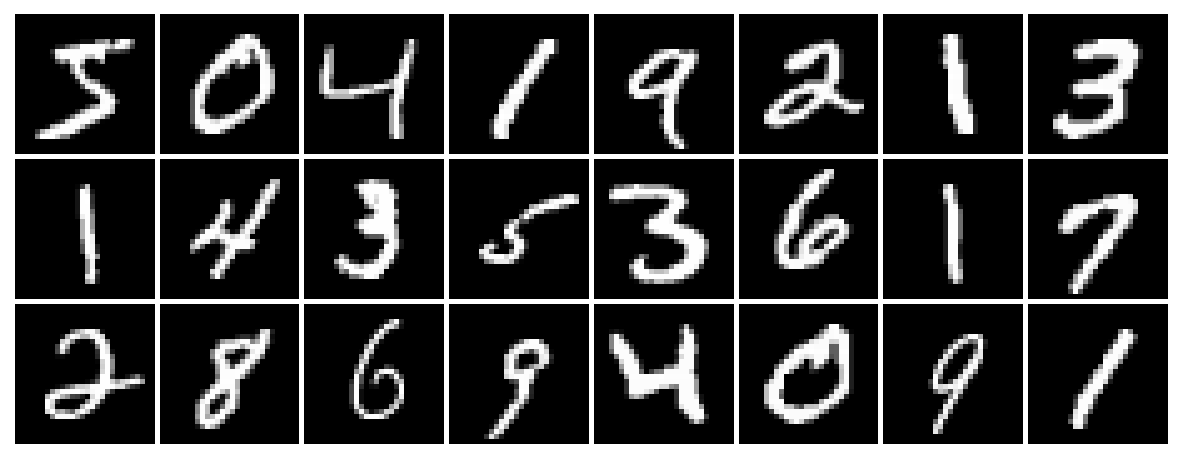

In [12]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


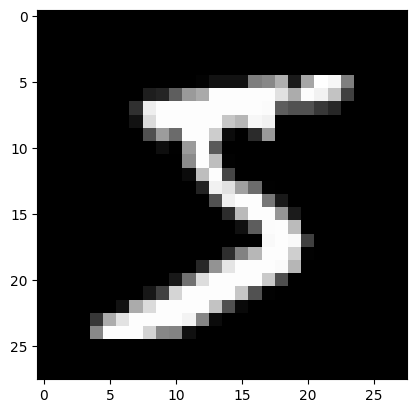

In [13]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [14]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [15]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.0835, -0.1636,  0.6375, -0.3941, -0.3117,  0.1618,  0.3385,  0.1409,
          0.4035,  0.2870],
        [-0.1418, -0.1753,  0.1624, -0.1070, -0.2192,  0.0394,  0.0146,  0.2387,
          0.4575,  0.1826],
        [ 0.1923, -0.1561, -0.0332,  0.1888,  0.0315, -0.1888, -0.0444,  0.3173,
          0.2256,  0.1304],
        [ 0.2991, -0.3171,  0.1723, -0.2360,  0.0066, -0.0294,  0.0597, -0.1055,
          0.1133,  0.1858],
        [ 0.1652, -0.0680,  0.2833, -0.1548, -0.1326,  0.1263,  0.1641, -0.0459,
          0.1982,  0.1739]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [16]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [17]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [18]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2644, Train Acc: 0.9410, Val Loss: 0.3995, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2631, Train Acc: 0.9430, Val Loss: 0.3986, Val Acc: 0.9000
Epoch [3/100], Train Loss: 0.2618, Train Acc: 0.9440, Val Loss: 0.3976, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2605, Train Acc: 0.9440, Val Loss: 0.3967, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2593, Train Acc: 0.9440, Val Loss: 0.3958, Val Acc: 0.9000
Epoch [6/100], Train Loss: 0.2580, Train Acc: 0.9440, Val Loss: 0.3949, Val Acc: 0.9000
Epoch [7/100], Train Loss: 0.2568, Train Acc: 0.9440, Val Loss: 0.3940, Val Acc: 0.9000
Epoch [8/100], Train Loss: 0.2555, Train Acc: 0.9440, Val Loss: 0.3931, Val Acc: 0.9000
Epoch [9/100], Train Loss: 0.2543, Train Acc: 0.9440, Val Loss: 0.3923, Val Acc: 0.9000
Epoch [10/100], Train Loss: 0.2531, Train Acc: 0.9440, Val Loss: 0.3915, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2519, Train Acc: 0.9440, Val Loss: 0.3906, Val Acc: 0.9000
Epoch [12/100], Train Loss: 0.

In [19]:
print('Final loss:', loss.item())

Final loss: 0.2657741606235504


### Visualizando gráfico de perda durante o treinamento

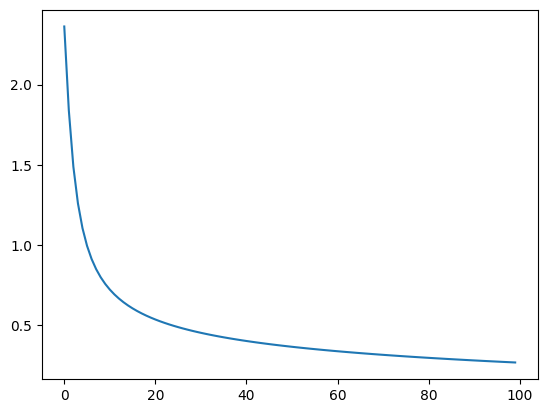

In [20]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

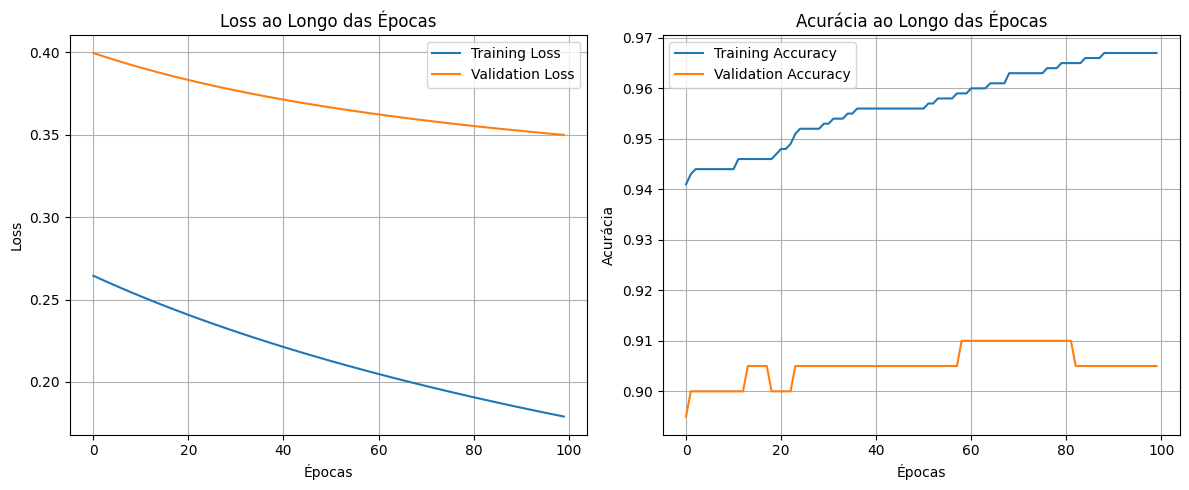

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [22]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [23]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


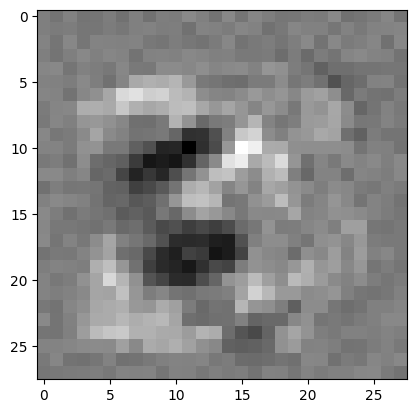

In [24]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

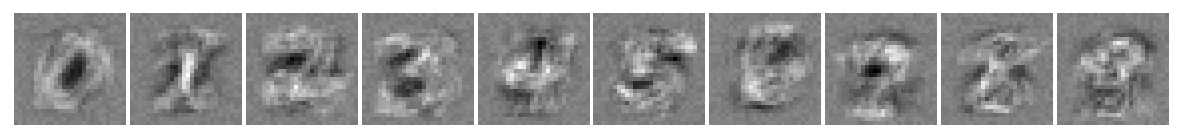

In [25]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [26]:
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()  # <--- Os gradientes são calculados aqui!
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print(f'Epoch [{i+1}/{epochs}], Loss: {loss.item():.6f}, Accuracy: {accuracy:.6f}')

Epoch [1/100], Loss: 0.178458, Accuracy: 0.967000
Epoch [2/100], Loss: 0.177884, Accuracy: 0.967000
Epoch [3/100], Loss: 0.177313, Accuracy: 0.967000
Epoch [4/100], Loss: 0.176745, Accuracy: 0.967000
Epoch [5/100], Loss: 0.176181, Accuracy: 0.967000
Epoch [6/100], Loss: 0.175620, Accuracy: 0.967000
Epoch [7/100], Loss: 0.175063, Accuracy: 0.967000
Epoch [8/100], Loss: 0.174509, Accuracy: 0.967000
Epoch [9/100], Loss: 0.173959, Accuracy: 0.967000
Epoch [10/100], Loss: 0.173412, Accuracy: 0.967000
Epoch [11/100], Loss: 0.172868, Accuracy: 0.967000
Epoch [12/100], Loss: 0.172327, Accuracy: 0.967000
Epoch [13/100], Loss: 0.171789, Accuracy: 0.967000
Epoch [14/100], Loss: 0.171255, Accuracy: 0.967000
Epoch [15/100], Loss: 0.170724, Accuracy: 0.967000
Epoch [16/100], Loss: 0.170196, Accuracy: 0.967000
Epoch [17/100], Loss: 0.169671, Accuracy: 0.967000
Epoch [18/100], Loss: 0.169149, Accuracy: 0.967000
Epoch [19/100], Loss: 0.168630, Accuracy: 0.967000
Epoch [20/100], Loss: 0.168114, Accuracy

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

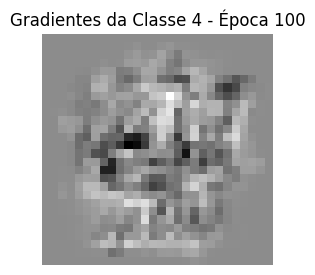

In [27]:
gradientes = model.weight.grad

grad_classe_4 = gradientes[4, :].detach().numpy().reshape((28, 28))

plt.figure(figsize=(3, 3))
plt.imshow(grad_classe_4, cmap='gray')
plt.title(f'Gradientes da Classe 4 - Época {i+1}')
plt.axis('off')
plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados


**Qual é o shape da matriz de entrada na rede?**

O shape da matriz de entrada para a rede neural é (N, 784), onde N é o número de amostras no lote (batch).

Cada imagem original tem as dimensões de 28*28 pixels. Como estamos utilizando uma camada linear (torch.nn.Linear), precisamos achatar essa imagem em um único vetor unidimensional de tamanho 28*28 = 784. No código, isso é feito pelo comando x_train.view(-1, 28 * 28). Para o seu conjunto de treinamento de 1000 amostras, o shape exato na passada de treino é (1000, 784).

**Qual é o shape da saída da rede?**

A camada linear foi definida como torch.nn.Linear(28*28, 10). O número 10 corresponde às 10 classes possíveis do dataset MNIST (os dígitos de 0 a 9). Para cada imagem de entrada, a rede gera 10 valores (logits/scores) indicando a probabilidade da imagem pertencer a cada uma das classes.

**Qual é o número total de parâmetros da rede, incluindo o bias?**

Pesos (Weights): 784 atributos de entrada multiplicados por 10 neurônios de saída = 7840 pesos.

Viés (Bias): 1 valor de viés para cada um dos 10 neurônios de saída = 10 vieses.

Total: 7840 + 10 = 7850 parâmetros treináveis.